# Import Libraries

In [1]:
import random
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import models, transforms

In [2]:
from aux_functions import *

In [18]:
class APTOSDataset(Dataset):
    def __init__(self, ann_file, image_dir, transform=None, mode='single', test=False):
        self.ann_file = ann_file
        self.image_dir = image_dir
        self.transform = transform

        self.test = test
        self.mode = mode

        if self.mode == 'single':
            self.data = self.load_data()
        else:
            self.data = self.load_dual_data()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        if self.mode == 'single':
            return self.get_item(index)
        else:
            return self.get_item_dual(index)

    # 1. single image
    def load_data(self):
        df = pd.read_csv(self.ann_file)

        data = []
        for _, row in df.iterrows():
            file_info = dict()
            file_info['img_path'] = os.path.join(self.image_dir, row['id_code'] + '.png')
            if not self.test:
                file_info['dr_level'] = int(row['diagnosis'])
            data.append(file_info)
        return data

    def get_item(self, index):
        data = self.data[index]
        img = Image.open(data['img_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)

        if not self.test:
            label = torch.tensor(data['dr_level'], dtype=torch.int64)
            return img, label
        else:
            return img

    # 2. dual image
    def load_dual_data(self):
        df = pd.read_csv(self.ann_file)

        df['prefix'] = df['id_code'].str.split('_').str[0]  # The patient id of each image
        df['suffix'] = df['id_code'].str.split('_').str[1].str[0]  # The left or right eye
        grouped = df.groupby(['prefix'])

        data = []
        for prefix, group in grouped:
            if len(group) == 2:  # Ensure there are two images (left and right eye) for the patient
                file_info = dict()
                file_info['img_path1'] = os.path.join(self.image_dir, group.iloc[0]['id_code'] + '.png')
                file_info['img_path2'] = os.path.join(self.image_dir, group.iloc[1]['id_code'] + '.png')
                if not self.test:
                    file_info['dr_level'] = int(group.iloc[0]['diagnosis'])
                data.append(file_info)
        return data

    def get_item_dual(self, index):
        data = self.data[index]
        img1 = Image.open(data['img_path1']).convert('RGB')
        img2 = Image.open(data['img_path2']).convert('RGB')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        if not self.test:
            label = torch.tensor(data['dr_level'], dtype=torch.int64)
            return [img1, img2], label
        else:
            return [img1, img2]

# Augmentation Functions

In [12]:
class CutOut(object):
    def __init__(self, mask_size, p=0.5):
        self.mask_size = mask_size
        self.p = p

    def __call__(self, img):
        if np.random.rand() > self.p:
            return img

        # Ensure the image is a tensor
        if not isinstance(img, torch.Tensor):
            raise TypeError('Input image must be a torch.Tensor')

        # Get height and width of the image
        h, w = img.shape[1], img.shape[2]
        mask_size_half = self.mask_size // 2
        offset = 1 if self.mask_size % 2 == 0 else 0

        cx = np.random.randint(mask_size_half, w + offset - mask_size_half)
        cy = np.random.randint(mask_size_half, h + offset - mask_size_half)

        xmin, xmax = cx - mask_size_half, cx + mask_size_half + offset
        ymin, ymax = cy - mask_size_half, cy + mask_size_half + offset
        xmin, xmax = max(0, xmin), min(w, xmax)
        ymin, ymax = max(0, ymin), min(h, ymax)

        img[:, ymin:ymax, xmin:xmax] = 0
        return img
    
class SLORandomPad:
    def __init__(self, size):
        self.size = size

    def __call__(self, img):
        pad_width = max(0, self.size[0] - img.width)
        pad_height = max(0, self.size[1] - img.height)
        pad_left = random.randint(0, pad_width)
        pad_top = random.randint(0, pad_height)
        pad_right = pad_width - pad_left
        pad_bottom = pad_height - pad_top
        return transforms.functional.pad(img, (pad_left, pad_top, pad_right, pad_bottom))


class FundRandomRotate:
    def __init__(self, prob, degree):
        self.prob = prob
        self.degree = degree

    def __call__(self, img):
        if random.random() < self.prob:
            angle = random.uniform(-self.degree, self.degree)
            return transforms.functional.rotate(img, angle)
        return img

b) Two stage training with additional dataset(s). (5 points)  
1. Choose a diabetic retinopathy dataset from either APTOS 2019 Blindness Detection or Kaggle 
DR Resized (links are provided below). 
2. Fine-tune an ImageNet pretrained model (e.g., ResNet18, ResNet34, VGG, EfficientNet, 
DenseNet) on the selected dataset by unfreezing all pretrained layers. 
3. Next up, fine-tune this trained model on the DeepDRiD dataset (keep all the layers frozen 
except the final one) and see how it impacts your Cohen Kappa score. 
4. Save the fine-tuned model.

In [13]:
class SingleModels(nn.Module):
    def __init__(self, model_name, num_classes=5):
        super().__init__()
        self.model_name = model_name
        if self.model_name == 'resnet18':
            self.backbone = models.resnet18(pretrained=True)
            num_ftrs = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()  # Remove the original classification layer
            self.fc = nn.Linear(num_ftrs, num_classes)
        elif self.model_name == 'resnet34':
            self.backbone = models.resnet34(pretrained=True)
            num_ftrs = self.backbone.fc.in_features 
            self.backbone.fc = nn.Identity()  # Remove the original classification layer
            self.fc = nn.Linear(num_ftrs, num_classes)
        elif self.model_name == 'vgg16':
            self.backbone = models.vgg16(pretrained=True)
            num_ftrs = self.backbone.classifier[6].in_features
            self.backbone.classifier[6] = nn.Linear(num_ftrs, num_classes)
        elif self.model_name == 'efficientnet_b0':
            self.backbone = models.efficientnet_b0(pretrained=True)
            num_ftrs = self.backbone.classifier[1].in_features
            self.backbone.classifier[1] = nn.Linear(num_ftrs, num_classes)
        elif self.model_name == 'densenet121':
            self.backbone = models.densenet121(pretrained=True)
            num_ftrs = self.backbone.classifier.in_features
            self.backbone.classifier = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        if self.model_name in ['resnet18', 'resnet34']:
            x = self.fc(x)
        return x
    

# Hyper Parameters

In [5]:
# Hyper Parameters
batch_size = 24
num_classes = 5  # 5 DR levels
learning_rate = 0.0001
num_epochs = 10

# Transformers

In [14]:
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((210, 210)),
    SLORandomPad((224, 224)),
    FundRandomRotate(prob=0.5, degree=30),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=(0.1, 0.9)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Main Loop

In [15]:
# Define the weighted CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

# Use GPU device is possible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


# Single Models

In [16]:
# Choose between 'single image' and 'dual images' pipeline
# This will affect the model definition, dataset pipeline, training and evaluation

mode = 'single'  # forward single image to the model each time

In [19]:
# Create datasets
train_dataset = APTOSDataset('./APTOS/train.csv', './APTOS/train_images/', transform_train, mode)
val_dataset = APTOSDataset('./APTOS/valid.csv', './APTOS/val_images/', transform_test, mode)
test_dataset = APTOSDataset('./APTOS/test.csv', './APTOS/test_images/', transform_test, mode, test=True)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

ResNet18

In [20]:
model_name = 'resnet18' # s:0.7805
# Define the model
model = SingleModels(model_name)

print(model, '\n')
print('Pipeline Mode:', mode)

# Move class weights to the device
model = model.to(device)

# Optimizer and Learning rate scheduler
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Train and evaluate the model with the training and validation set
model, training_loss, validation_loss, training_accuracy, validation_accuracy, train_kappa, val_kappa_list = train_model(
    model, train_loader, val_loader, device, criterion, optimizer,
    lr_scheduler=lr_scheduler, num_epochs=num_epochs,
    checkpoint_path='./resnet18.pth'
)

# Load the pretrained checkpoint
state_dict = torch.load('./resnet18.pth', map_location='cpu')
model.load_state_dict(state_dict, strict=True)

# Make predictions on testing set and save the prediction results
evaluate_model(criterion, model, test_loader, device, test_only=True, prediction_path='./test_predictions_resnet18.csv')

epochs_range = range(1, num_epochs + 1)

# Plot Loss
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.plot(epochs_range, training_loss, label="Training Loss")
plt.plot(epochs_range, validation_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs_range, training_accuracy, label="Training Accuracy")
plt.plot(epochs_range, validation_accuracy, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Plot Kappa Score
plt.subplot(1, 3, 3)
plt.plot(epochs_range, train_kappa, label="Training Kappa Score")
plt.plot(epochs_range, val_kappa_list, label="Validation Kappa Score")
plt.xlabel("Epochs")
plt.ylabel("Kappa Score")
plt.title("Training vs Validation Kappa Score")
plt.legend()
plt.tight_layout()
plt.show()

c:\Users\murat\anaconda3\envs\project\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\murat\anaconda3\envs\project\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


SingleModels(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

KeyboardInterrupt: 

ResNet34

c:\Users\murat\anaconda3\envs\project\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\murat\anaconda3\envs\project\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


SingleModels(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

C:\Users\murat\AppData\Local\Temp\ipykernel_15820\1970275383.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('./model_1.pth', map_location='cpu'


[Val] Kappa: 0.6217 Accuracy: 0.4650 Precision: 0.5923 Recall: 0.4650
[Val] Best kappa: 0.7777, Epoch 1
Evaluating: 100%|██████████| 17/17 [00:02<00:00,  7.19 batch/s]
[Test] Save predictions to c:\Users\murat\Documents\Deep_Learning\Final Project\test_predictions.csv


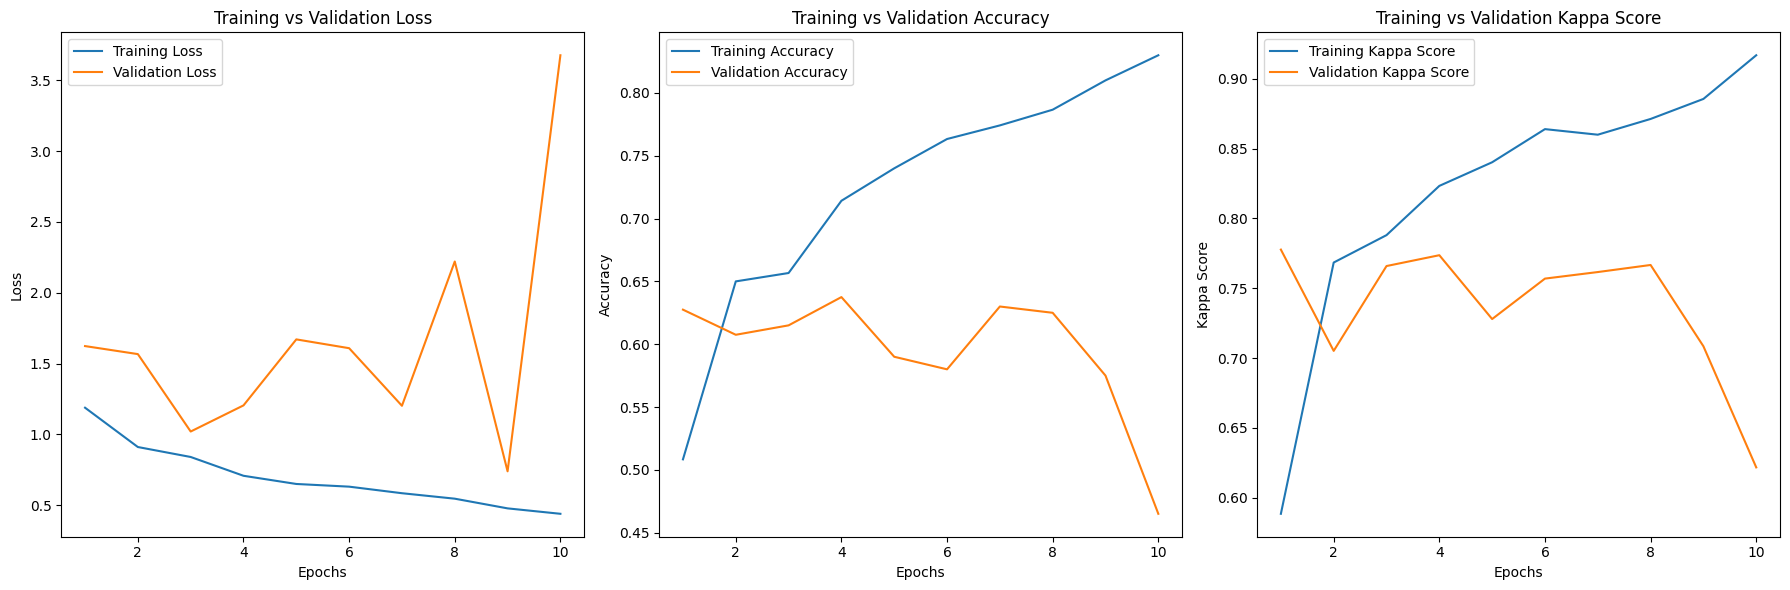

In [19]:
model_name = 'resnet34' # s:0.7814
# Define the model
model = SingleModels(model_name)

print(model, '\n')
print('Pipeline Mode:', mode)

# Move class weights to the device
model = model.to(device)

# Optimizer and Learning rate scheduler
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Train and evaluate the model with the training and validation set
model, training_loss, validation_loss, training_accuracy, validation_accuracy, train_kappa, val_kappa_list = train_model(
    model, train_loader, val_loader, device, criterion, optimizer,
    lr_scheduler=lr_scheduler, num_epochs=num_epochs,
    checkpoint_path='./resnet34.pth'
)

# Load the pretrained checkpoint
state_dict = torch.load('./resnet34.pth', map_location='cpu')
model.load_state_dict(state_dict, strict=True)

# Make predictions on testing set and save the prediction results
evaluate_model(criterion, model, test_loader, device, test_only=True, prediction_path='./test_predictions_resnet34.csv')

epochs_range = range(1, num_epochs + 1)

# Plot Loss
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.plot(epochs_range, training_loss, label="Training Loss")
plt.plot(epochs_range, validation_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs_range, training_accuracy, label="Training Accuracy")
plt.plot(epochs_range, validation_accuracy, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Plot Kappa Score
plt.subplot(1, 3, 3)
plt.plot(epochs_range, train_kappa, label="Training Kappa Score")
plt.plot(epochs_range, val_kappa_list, label="Validation Kappa Score")
plt.xlabel("Epochs")
plt.ylabel("Kappa Score")
plt.title("Training vs Validation Kappa Score")
plt.legend()
plt.tight_layout()
plt.show()

VGG

SingleModels(
  (backbone): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
    

C:\Users\murat\AppData\Local\Temp\ipykernel_15820\781242875.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('./model_1.pth', map_location='cpu')

Evaluating: 100%|██████████| 17/17 [01:10<00:00,  4.15s/ batch]
[Test] Save predictions to c:\Users\murat\Documents\Deep_Learning\Final Project\test_predictions.csv


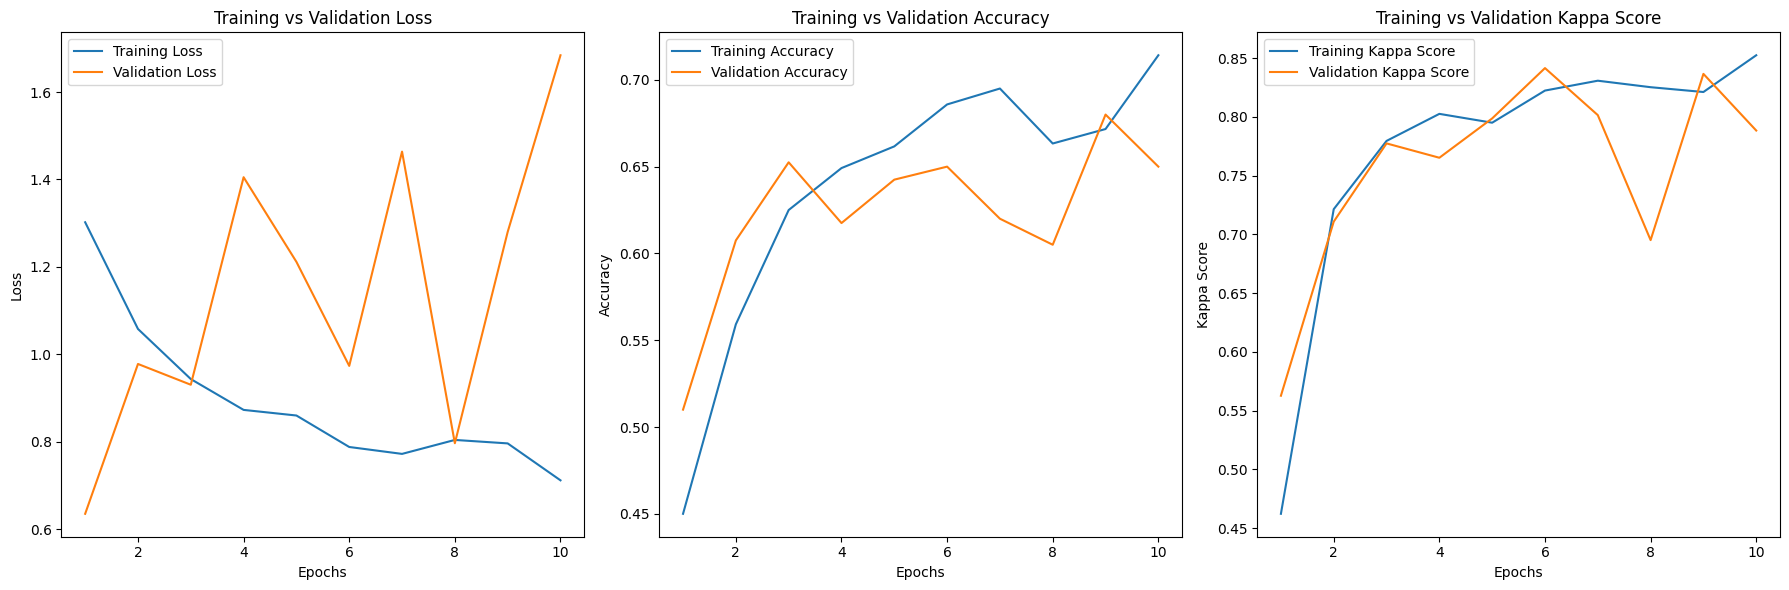

In [34]:
model_name = 'vgg16'
# Define the model
model = SingleModels(model_name)

print(model, '\n')
print('Pipeline Mode:', mode)

# Move class weights to the device
model = model.to(device)

# Optimizer and Learning rate scheduler
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Train and evaluate the model with the training and validation set
model, training_loss, validation_loss, training_accuracy, validation_accuracy, train_kappa, val_kappa_list = train_model(
    model, train_loader, val_loader, device, criterion, optimizer,
    lr_scheduler=lr_scheduler, num_epochs=num_epochs,
    checkpoint_path='./vgg16.pth'
)

# Load the pretrained checkpoint
state_dict = torch.load('./vgg16.pth', map_location='cpu')
model.load_state_dict(state_dict, strict=True)

# Make predictions on testing set and save the prediction results
evaluate_model(criterion, model, test_loader, device, test_only=True, prediction_path='./test_predictions_vgg16.csv')

epochs_range = range(1, num_epochs + 1)

# Plot Loss
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.plot(epochs_range, training_loss, label="Training Loss")
plt.plot(epochs_range, validation_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs_range, training_accuracy, label="Training Accuracy")
plt.plot(epochs_range, validation_accuracy, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Plot Kappa Score
plt.subplot(1, 3, 3)
plt.plot(epochs_range, train_kappa, label="Training Kappa Score")
plt.plot(epochs_range, val_kappa_list, label="Validation Kappa Score")
plt.xlabel("Epochs")
plt.ylabel("Kappa Score")
plt.title("Training vs Validation Kappa Score")
plt.legend()
plt.tight_layout()
plt.show()

EfficientNet

SingleModels(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (scale

C:\Users\murat\AppData\Local\Temp\ipykernel_15820\4207833069.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('./efficientnet_b0.pth', map_locati


[Val] Kappa: 0.7260 Accuracy: 0.6300 Precision: 0.6077 Recall: 0.6300
[Val] Best kappa: 0.7520, Epoch 9
Evaluating: 100%|██████████| 17/17 [00:05<00:00,  3.13 batch/s]
[Test] Save predictions to c:\Users\murat\Documents\Deep_Learning\Final Project\test_predictions_efficientnet_b0.csv


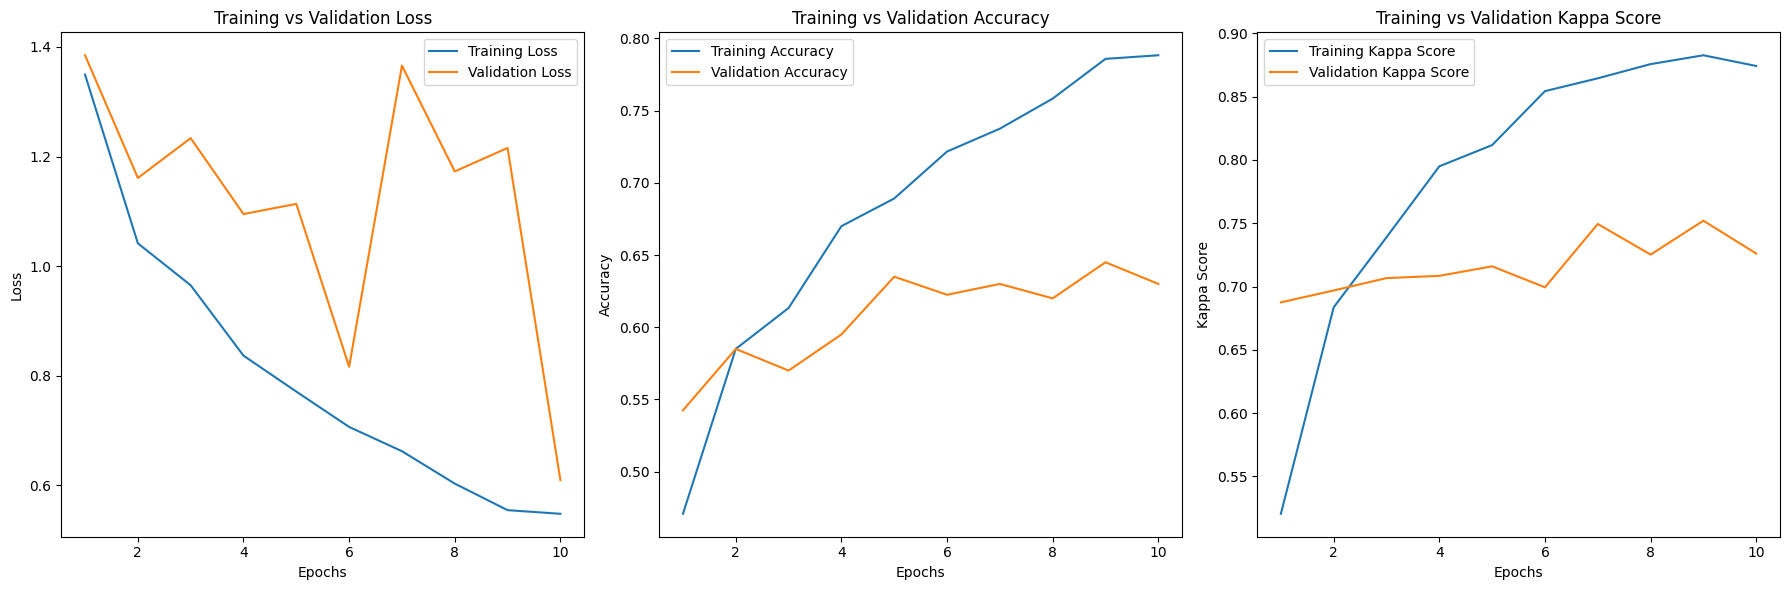

In [37]:
model_name = 'efficientnet_b0'
# Define the model
model = SingleModels(model_name)

print(model, '\n')
print('Pipeline Mode:', mode)

# Move class weights to the device
model = model.to(device)

# Optimizer and Learning rate scheduler
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Train and evaluate the model with the training and validation set
model, training_loss, validation_loss, training_accuracy, validation_accuracy, train_kappa, val_kappa_list = train_model(
    model, train_loader, val_loader, device, criterion, optimizer,
    lr_scheduler=lr_scheduler, num_epochs=num_epochs,
    checkpoint_path='./efficientnet_b0.pth'
)

# Load the pretrained checkpoint
state_dict = torch.load('./efficientnet_b0.pth', map_location='cpu')
model.load_state_dict(state_dict, strict=True)

# Make predictions on testing set and save the prediction results
evaluate_model(criterion, model, test_loader, device, test_only=True, prediction_path='./test_predictions_efficientnet_b0.csv')

epochs_range = range(1, num_epochs + 1)

# Plot Loss
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.plot(epochs_range, training_loss, label="Training Loss")
plt.plot(epochs_range, validation_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs_range, training_accuracy, label="Training Accuracy")
plt.plot(epochs_range, validation_accuracy, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Plot Kappa Score
plt.subplot(1, 3, 3)
plt.plot(epochs_range, train_kappa, label="Training Kappa Score")
plt.plot(epochs_range, val_kappa_list, label="Validation Kappa Score")
plt.xlabel("Epochs")
plt.ylabel("Kappa Score")
plt.title("Training vs Validation Kappa Score")
plt.legend()
plt.tight_layout()
plt.show()

DenseNet

c:\Users\murat\anaconda3\envs\project\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\murat\anaconda3\envs\project\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


SingleModels(
  (backbone): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, moment

C:\Users\murat\AppData\Local\Temp\ipykernel_15820\3115768214.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('./densenet121.pth', map_location='


[Val] Kappa: 0.7927 Accuracy: 0.6250 Precision: 0.6011 Recall: 0.6250
[Val] Best kappa: 0.8152, Epoch 3
Evaluating: 100%|██████████| 17/17 [00:07<00:00,  2.15 batch/s]
[Test] Save predictions to c:\Users\murat\Documents\Deep_Learning\Final Project\test_predictions_densenet121.csv


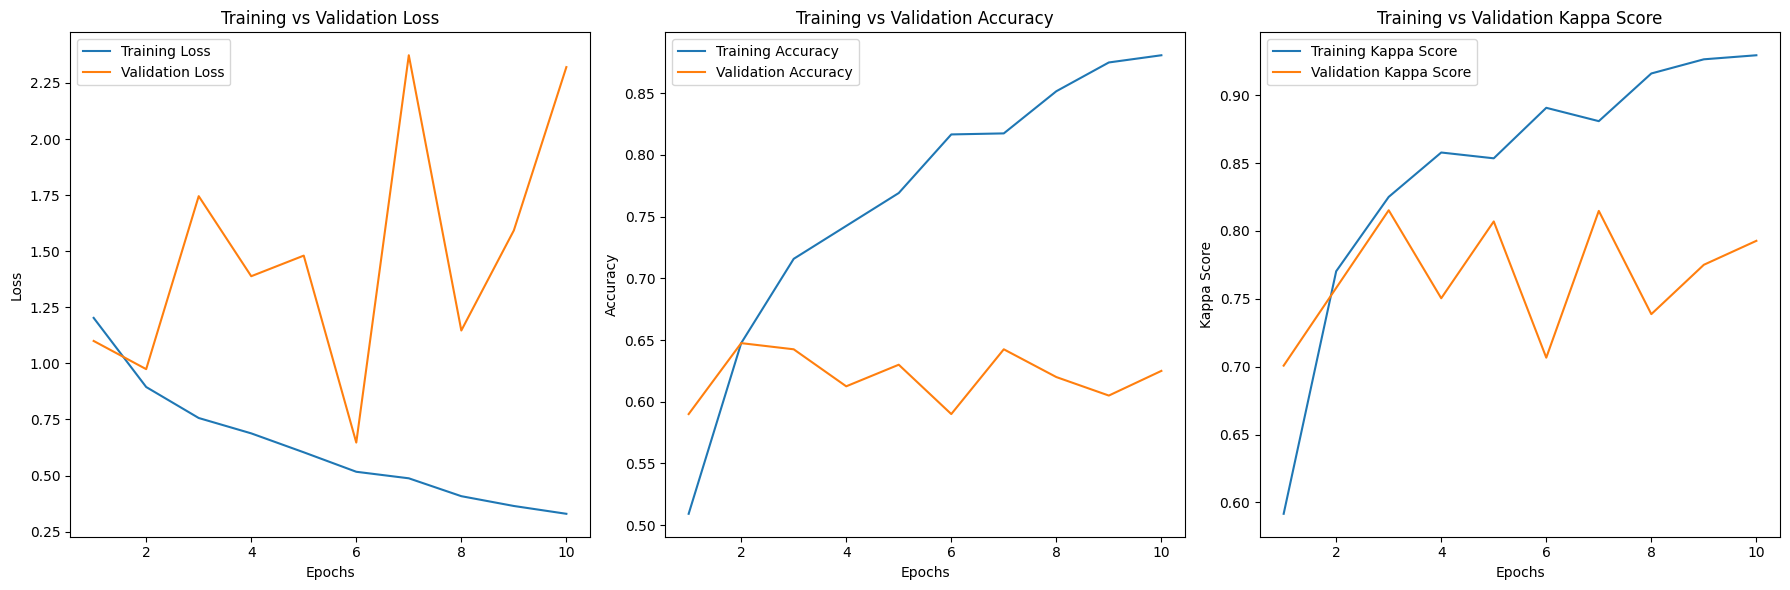

In [38]:
model_name = 'densenet121'
# Define the model
model = SingleModels(model_name)

print(model, '\n')
print('Pipeline Mode:', mode)

# Move class weights to the device
model = model.to(device)

# Optimizer and Learning rate scheduler
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Train and evaluate the model with the training and validation set
model, training_loss, validation_loss, training_accuracy, validation_accuracy, train_kappa, val_kappa_list = train_model(
    model, train_loader, val_loader, device, criterion, optimizer,
    lr_scheduler=lr_scheduler, num_epochs=num_epochs,
    checkpoint_path='./densenet121.pth'
)

# Load the pretrained checkpoint
state_dict = torch.load('./densenet121.pth', map_location='cpu')
model.load_state_dict(state_dict, strict=True)

# Make predictions on testing set and save the prediction results
evaluate_model(criterion, model, test_loader, device, test_only=True, prediction_path='./test_predictions_densenet121.csv')

epochs_range = range(1, num_epochs + 1)

# Plot Loss
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.plot(epochs_range, training_loss, label="Training Loss")
plt.plot(epochs_range, validation_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs_range, training_accuracy, label="Training Accuracy")
plt.plot(epochs_range, validation_accuracy, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Plot Kappa Score
plt.subplot(1, 3, 3)
plt.plot(epochs_range, train_kappa, label="Training Kappa Score")
plt.plot(epochs_range, val_kappa_list, label="Validation Kappa Score")
plt.xlabel("Epochs")
plt.ylabel("Kappa Score")
plt.title("Training vs Validation Kappa Score")
plt.legend()
plt.tight_layout()
plt.show()